<a href="https://colab.research.google.com/github/xyfuu/Leukemia-Cancer-Cell-Classification/blob/main/AndroidModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!unzip /content/drive/MyDrive/COLAB/Leukemia.zip -d ./data

Streaming output truncated to the last 5000 lines.
  inflating: ./data/Leukemia/UID_51_53_3_all.bmp  
  inflating: ./data/Leukemia/UID_51_54_1_all.bmp  
  inflating: ./data/Leukemia/UID_51_55_1_all.bmp  
  inflating: ./data/Leukemia/UID_51_56_1_all.bmp  
  inflating: ./data/Leukemia/UID_51_56_2_all.bmp  
  inflating: ./data/Leukemia/UID_51_56_3_all.bmp  
  inflating: ./data/Leukemia/UID_51_56_4_all.bmp  
  inflating: ./data/Leukemia/UID_51_56_5_all.bmp  
  inflating: ./data/Leukemia/UID_51_56_6_all.bmp  
  inflating: ./data/Leukemia/UID_51_56_7_all.bmp  
  inflating: ./data/Leukemia/UID_51_57_1_all.bmp  
  inflating: ./data/Leukemia/UID_51_57_2_all.bmp  
  inflating: ./data/Leukemia/UID_51_57_3_all.bmp  
  inflating: ./data/Leukemia/UID_51_57_4_all.bmp  
  inflating: ./data/Leukemia/UID_51_57_5_all.bmp  
  inflating: ./data/Leukemia/UID_51_57_6_all.bmp  
  inflating: ./data/Leukemia/UID_51_57_7_all.bmp  
  inflating: ./data/Leukemia/UID_51_58_1_all.bmp  
  inflating: ./data/Leukemia/UI

In [ ]:
import os
import shutil
import random

data_dir = 'data/Leukemia'
train_dir = 'train_data'
test_dir = 'test_data'
split_ratio = 0.8

os.makedirs(os.path.join(train_dir, 'normal'), exist_ok=True)
os.makedirs(os.path.join(train_dir, 'abnormal'), exist_ok=True)
os.makedirs(os.path.join(test_dir, 'normal'), exist_ok=True)
os.makedirs(os.path.join(test_dir, 'abnormal'), exist_ok=True)

normal_files = [f for f in os.listdir(data_dir) if f.endswith('all.bmp')]
abnormal_files = [f for f in os.listdir(data_dir) if f.endswith('hem.bmp')]

random.shuffle(normal_files)
random.shuffle(abnormal_files)

def split_data(files, split_ratio):
    split_point = int(len(files) * split_ratio)
    train_files = files[:split_point]
    test_files = files[split_point:]
    return train_files, test_files

normal_train, normal_test = split_data(normal_files, split_ratio)
abnormal_train, abnormal_test = split_data(abnormal_files, split_ratio)

In [ ]:
def copy_files(files, source_dir, target_dir):
  for file in files:
    shutil.copy(os.path.join(source_dir, file), os.path.join(target_dir, file))

copy_files(normal_train, data_dir, os.path.join(train_dir, 'normal'))
copy_files(normal_test, data_dir, os.path.join(test_dir, 'normal'))
copy_files(abnormal_train, data_dir, os.path.join(train_dir, 'abnormal'))
copy_files(abnormal_test, data_dir, os.path.join(test_dir, 'abnormal'))

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt

In [ ]:
img_height, img_width = 224, 224
batch_size = 20

train_ds = tf.keras.utils.image_dataset_from_directory(
    "train_data",
    image_size = (img_height, img_width),
    batch_size = batch_size
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    "test_data",
    image_size = (img_height, img_width),
    batch_size = batch_size
)

Found 8528 files belonging to 2 classes.
Found 2133 files belonging to 2 classes.


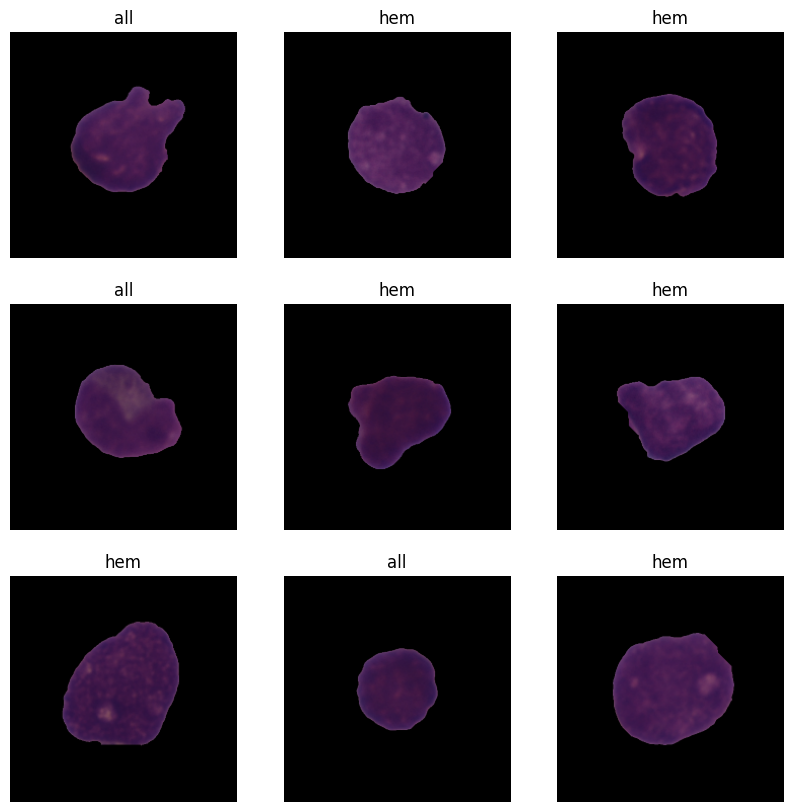

In [ ]:
class_names = ["all", "hem"]
plt.figure(figsize=(10,10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [ ]:
model = tf.keras.Sequential(
    [
     tf.keras.layers.Rescaling(1./255),
     tf.keras.layers.Conv2D(32, 3, activation="relu"),
     tf.keras.layers.MaxPooling2D(),
     tf.keras.layers.Conv2D(32, 3, activation="relu"),
     tf.keras.layers.MaxPooling2D(),
     tf.keras.layers.Conv2D(32, 3, activation="relu"),
     tf.keras.layers.MaxPooling2D(),
     tf.keras.layers.Flatten(),
     tf.keras.layers.Dense(128, activation="relu"),
     tf.keras.layers.Dense(3)
    ]
)

In [ ]:
model.compile(
    optimizer="adam",
    loss=tf.losses.SparseCategoricalCrossentropy(from_logits = True),
    metrics=['accuracy']
)

In [ ]:
model.fit(
    train_ds,
    validation_data = val_ds,
    epochs = 10
)

Epoch 1/10
427/427 ━━━━━━━━━━━━━━━━━━━━ 572s 1s/step - accuracy: 0.8005 - loss: 0.4933 - val_accuracy: 0.7764 - val_loss: 0.4915
Epoch 2/10
427/427 ━━━━━━━━━━━━━━━━━━━━ 565s 1s/step - accuracy: 0.8136 - loss: 0.4431 - val_accuracy: 0.7932 - val_loss: 0.4764
Epoch 3/10
427/427 ━━━━━━━━━━━━━━━━━━━━ 564s 1s/step - accuracy: 0.8275 - loss: 0.4135 - val_accuracy: 0.8209 - val_loss: 0.4185
Epoch 4/10
427/427 ━━━━━━━━━━━━━━━━━━━━ 626s 1s/step - accuracy: 0.8378 - loss: 0.3847 - val_accuracy: 0.8345 - val_loss: 0.4099
Epoch 5/10
427/427 ━━━━━━━━━━━━━━━━━━━━ 672s 1s/step - accuracy: 0.8499 - loss: 0.3564 - val_accuracy: 0.8218 - val_loss: 0.4443
Epoch 6/10
427/427 ━━━━━━━━━━━━━━━━━━━━ 567s 1s/step - accuracy: 0.8597 - loss: 0.3341 - val_accuracy: 0.7942 - val_loss: 0.5104
Epoch 7/10
427/427 ━━━━━━━━━━━━━━━━━━━━ 619s 1s/step - accuracy: 0.8714 - loss: 0.3014 - val_accuracy: 0.8383 - val_loss: 0.4742
Epoch 8/10
334/427 ━━━━━━━━━━━━━━━━━━━━ 1:54 1s/step - accuracy: 0.8878 - loss: 0.2675

In [ ]:
import numpy

plt.figure(figsize=(10,10))
for images, labels in val_ds.take(1):
  classifications = model(images)
  # print(classifications)

  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    index = numpy.argmax(classifications[i])
    plt.title("Pred: " + class_names[index] + " | Real: " + class_names[labels[i]])

In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open("android_model.tflite", 'wb') as f:
  f.write(tflite_model)